In [6]:
# Load bias data into memory
import os
import pandas as pd

# clone repo with more bias data
!rm -rf RedditBias
!git clone https://github.com/umanlp/RedditBias.git

base_path = "RedditBias/data"

all_data = pd.DataFrame()
encodings = ["utf-8", "latin1", "ISO-8859-1"]

for root, dirs, files in os.walk(base_path):
    for file in files:
        if file.endswith("annotated.csv"):
            file_path = os.path.join(root, file)
            df = None

            # Try reading with different encodings
            for enc in encodings:
                try:
                    df = pd.read_csv(file_path, encoding=enc)
                    print(f"Read {file} successfully with {enc}")
                    break
                except Exception as e:
                    print(f"Failed with {enc}: {e}")

            if df is None:
                print(f" Could not read {file} with any encoding.")
                continue

            # Select + rename columns
            if all(col in df.columns for col in ["comment", "bias_sent"]):
                df = df[["comment", "bias_sent"]].rename(
                    columns={
                        "comment": "text",
                        "bias_sent": "bias"
                    }
                )

                valid_labels = [ 0.0, 1.0]
                df = df[df["bias"].isin(valid_labels)].copy()

                all_data = pd.concat([all_data, df], ignore_index=True)
            else:
                print(f"Missing required columns in {file}: {df.columns}")

# remove repo                 
!rm -rf RedditBias

# clone repo with sexism bias
!rm -rf BiasData
!git clone https://github.com/MarcinZarkowski/BiasData.git

base_path = "BiasData/sexism_bias"
for root, dirs, files in os.walk(base_path):
  for file in files:
    file_path = os.path.join(root, file)
    df = None

    # Try reading with different encodings
    for enc in encodings:
        try:
            df = pd.read_csv(file_path, encoding=enc)
            print(f"Read {file} successfully with {enc}")
            break
        except Exception as e:
            print(f"Failed with {enc}: {e}")

    if df is None:
        print(f"Could not read {file} with any encoding.")
        continue

    # Select + rename columns
    if all(col in df.columns for col in ["text", "label_sexist"]):
        df = df[["text", "label_sexist"]].rename(
            columns={
                "text": "text",
                "label_sexist": "bias"
            }
        )
        df = df[df["bias"].isin(["sexist", "not sexist"])]

        df["bias"] = df["bias"].map({
            "not sexist": 0.0,
            "sexist": 1.0
        })
        all_data = pd.concat([all_data, df], ignore_index=True)
    else:
        print(f"Missing required columns in {file}: {df.columns}")

# delete cloned repo 
!rm -rf BiasData

print("Final all_data shape:", all_data.shape)

Cloning into 'RedditBias'...
remote: Enumerating objects: 1061, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 1061 (delta 0), reused 0 (delta 0), pack-reused 1058 (from 1)
Receiving objects: 100% (1061/1061), 34.70 MiB | 36.78 MiB/s, done.
Resolving deltas: 100% (699/699), done.
Read reddit_comments_religion2_muslims_processed_phrase_annotated.csv successfully with utf-8
Read reddit_comments_orientation_lgbtq_processed_phrase_annotated.csv successfully with utf-8
Read reddit_comments_gender_female_processed_phrase_annotated.csv successfully with utf-8
Failed with utf-8: 'utf-8' codec can't decode byte 0xd5 in position 75: invalid continuation byte
Read reddit_comments_religion1_jews_processed_phrase_annotated.csv successfully with latin1
Read reddit_comments_race_black_processed_phrase_annotated.csv successfully with utf-8


/var/folders/j9/pd3d04x538n0fy59bs7fl6840000gn/T/ipykernel_23140/3028072279.py:45: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  all_data = pd.concat([all_data, df], ignore_index=True)


Cloning into 'BiasData'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 13 (delta 1), reused 10 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), 5.26 MiB | 20.78 MiB/s, done.
Resolving deltas: 100% (1/1), done.
Read train (2).csv successfully with utf-8
Read test (1).csv successfully with utf-8
Read dev.csv successfully with utf-8
Final all_data shape: (29381, 2)


In [7]:
import pandas as pd
import re

def clean_text(text):
    if pd.isna(text):
        return ""

    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)

    text = re.sub(r"[^\w\s.,!?'-]", "", text, flags=re.UNICODE)

    text = re.sub(r"\s+", " ", text).strip()

    return text

all_data = all_data.loc[:, ~all_data.columns.str.contains('^Unnamed')]

all_data = all_data.drop_duplicates().dropna()

all_data["text"] = all_data["text"].apply(clean_text)

all_data = all_data[all_data["text"] != ""].reset_index(drop=True)

print("After cleaning:", all_data.shape)

After cleaning: (29379, 2)


In [ ]:
#Save final dataset next to model training notebook

save_path = os.path.join("../model_training", "all_data.csv")

all_data.to_csv(save_path, index=False, encoding="utf-8")
print(f"Saved clean dataset to yor drive: {save_path}")

Saved clean dataset to yor drive: ../model_training/all_data.csv


count    29379.000000
mean       114.653120
std         57.510415
min          4.000000
25%         69.000000
50%        108.000000
75%        148.000000
max        250.000000
Name: text_length, dtype: float64


<Axes: xlabel='bias'>

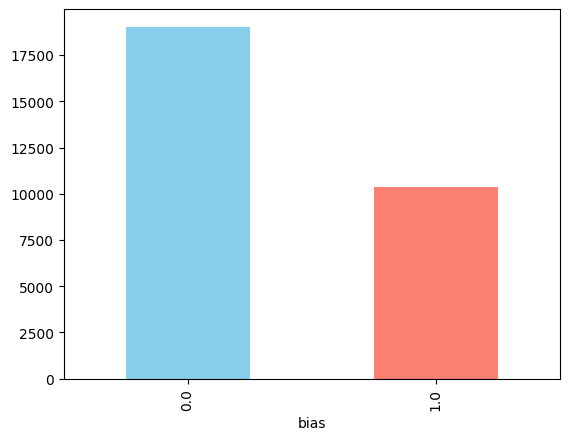

In [9]:
import matplotlib as plt
import pandas as pd

all_data = pd.read_csv('../model_training/all_data.csv')
all_data['text_length'] = all_data['text'].astype(str).apply(len)
print(all_data['text_length'].describe())

all_data['bias'].value_counts().plot(kind='bar', color=['skyblue','salmon'])